In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
#Enter own path
df = pd.read_csv("/home/hj-anand/Documents/AIML/regression_housing_data.csv")

# Display first 5 rows
print(df.head(10))

   SquareFootage  Bedrooms  Bathrooms  AgeYears  DistanceToCenterMiles   Price
0           3974         3        3.0        32                   2.73  886534
1           1660         1        1.0        21                   8.58  393833
2           2094         4        3.5        20                  17.34  520649
3           1930         2        1.5         5                  18.50  443332
4           1895         2        1.5         5                   9.58  498636
5           3892         1        1.0        47                   9.88  693023
6           2438         3        3.0         3                  18.41  606614
7           2969         3        3.5        29                  11.95  685510
8           1266         1        1.0        10                   1.14  378027
9           2038         3        2.0        29                  18.30  454640


In [ ]:
print(df.columns.tolist())

['SquareFootage', 'Bedrooms', 'Bathrooms', 'AgeYears', 'DistanceToCenterMiles', 'Price']


In [ ]:
TARGET_COLUMN = "Price"

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

print(X.head())
print(y.head())

   SquareFootage  Bedrooms  Bathrooms  AgeYears  DistanceToCenterMiles
0           3974         3        3.0        32                   2.73
1           1660         1        1.0        21                   8.58
2           2094         4        3.5        20                  17.34
3           1930         2        1.5         5                  18.50
4           1895         2        1.5         5                   9.58
0    886534
1    393833
2    520649
3    443332
4    498636
Name: Price, dtype: int64


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "SVR": SVR()
}

In [ ]:
results = []

for name, model in models.items():

    # Models requiring scaled data
    if name in [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "KNN Regressor",
        "SVR"
    ]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append([name, mae, mse, rmse, r2])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df)

               Model            MAE           MSE           RMSE  R2 Score
0  Linear Regression   21890.571599  7.645195e+08   27649.945606  0.970796
2   Lasso Regression   21891.049065  7.645428e+08   27650.366805  0.970795
1   Ridge Regression   21899.998586  7.683756e+08   27719.589175  0.970649
7        Extra Trees   28195.534200  1.294337e+09   35976.889068  0.950557
5      Random Forest   28111.192400  1.317775e+09   36301.173843  0.949662
6  Gradient Boosting   28890.101215  1.432399e+09   37847.049119  0.945283
8           AdaBoost   35308.892948  1.852641e+09   43042.314127  0.929231
4      Decision Tree   38134.380000  2.395303e+09   48941.829357  0.908501
3      KNN Regressor   40886.216000  2.619214e+09   51178.261588  0.899948
9                SVR  136380.887315  2.645064e+10  162636.537555 -0.010394


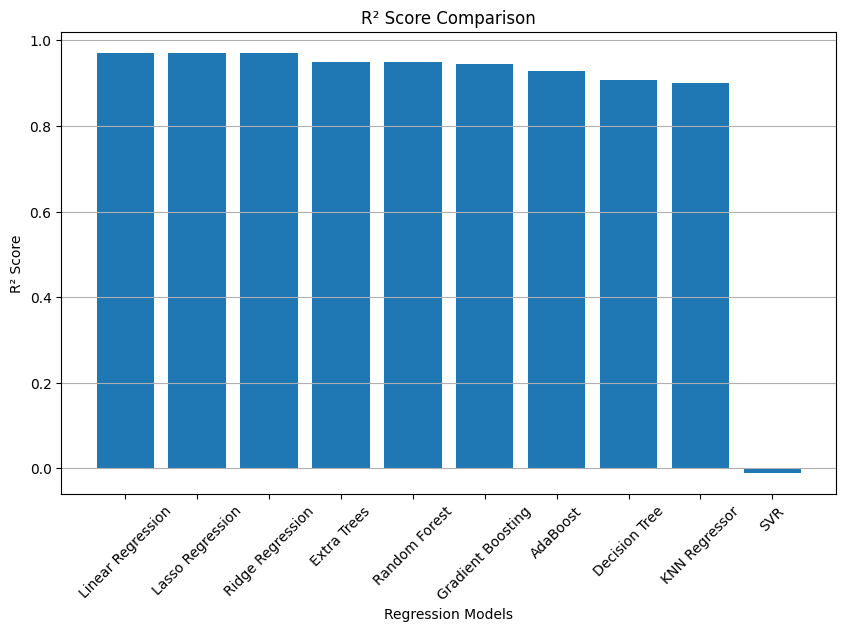

In [ ]:
import matplotlib.pyplot as plt

# Sort by R² Score
results_df = results_df.sort_values(by="R2 Score", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("R² Score Comparison")
plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

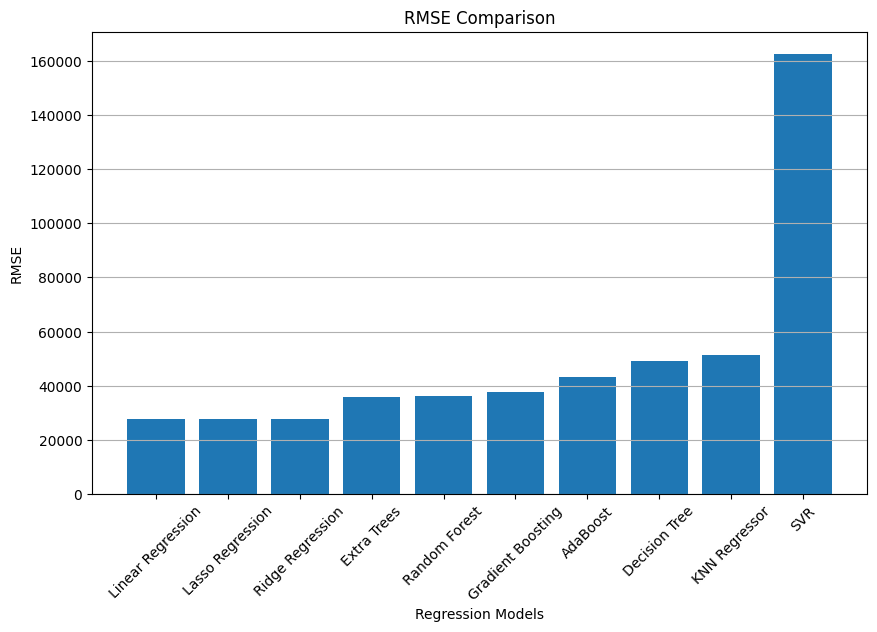

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

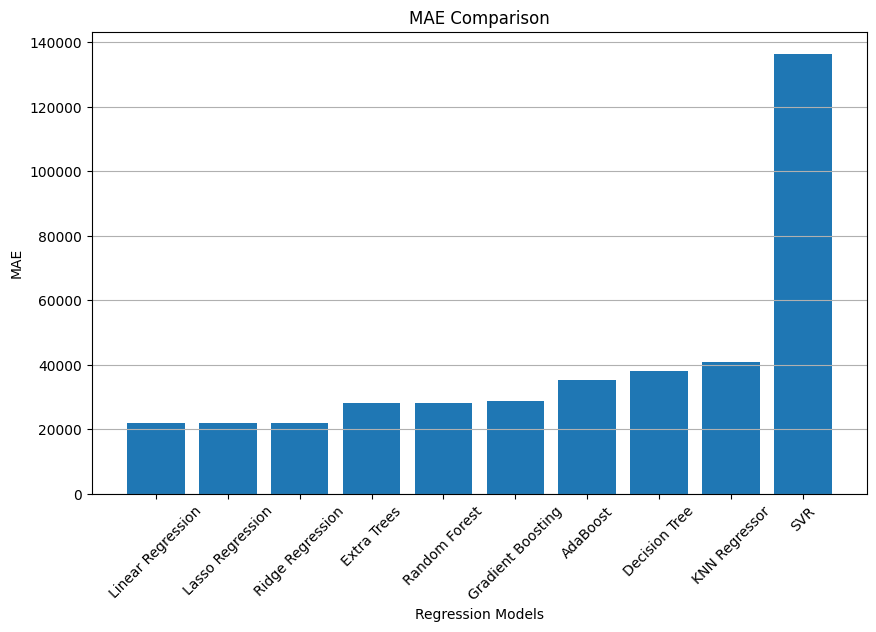

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("MAE Comparison")
plt.xlabel("Regression Models")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

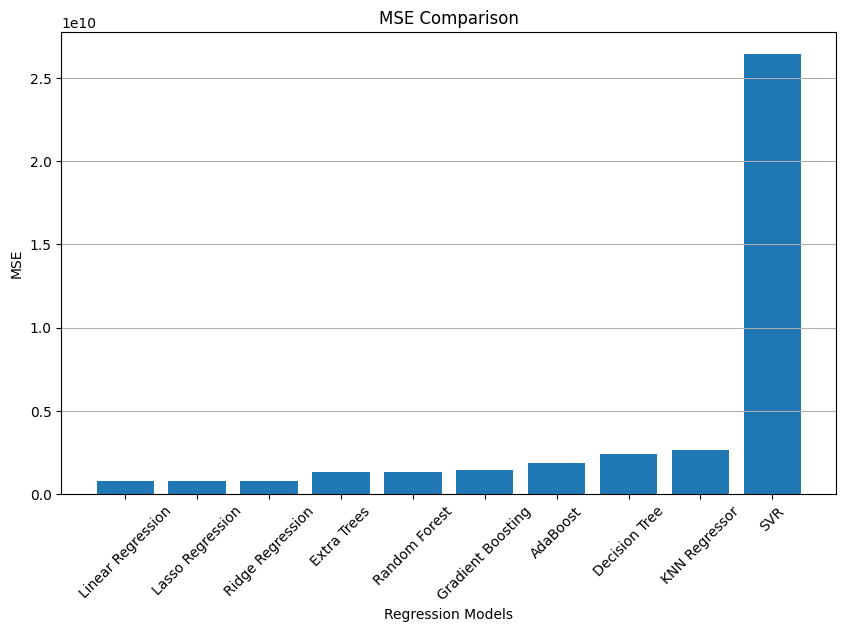

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["MSE"])
plt.title("MSE Comparison")
plt.xlabel("Regression Models")
plt.ylabel("MSE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

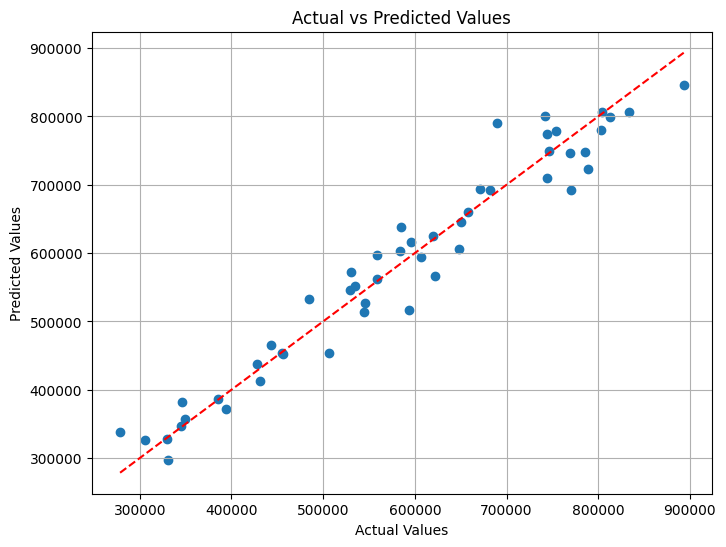

In [ ]:
# Example: Random Forest
best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()

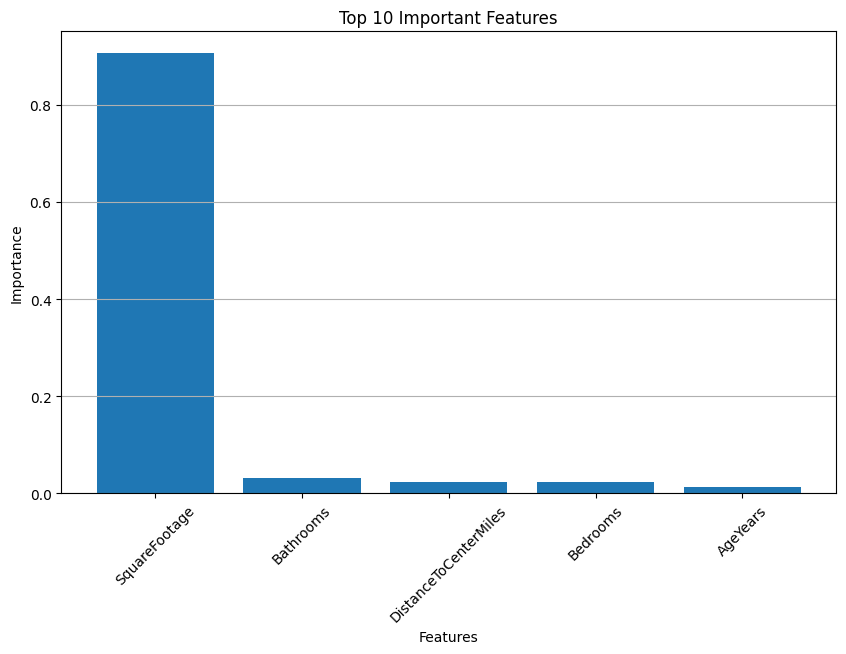

In [ ]:
++++++++

In [ ]:
from google.colab import drive
drive.mount('/content/drive')